<a href="https://colab.research.google.com/github/bjoaquin19/1ra_evaluacion_mineria/blob/main/EV1_ADICCION_CELULARES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


In [ ]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

In [ ]:
#Creando el dataset y cargando el csv
df = pd.read_csv("/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

In [ ]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [ ]:
#Comprobando si hay algun dato nulo en la base de datos
df.isnull().any().any()

np.True_

In [ ]:
#Cantidad de datos nulos por cada columna
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


In [ ]:
#Verificamos cuantas filas y columnas tiene la tabla
df.shape

(7500, 16)

In [ ]:
df.dtypes #observamos la columna y sus tipos de datos

,0
transaction_id,object
user_id,object
age,int64
gender,object
daily_screen_time_hours,float64
social_media_hours,float64
gaming_hours,float64
work_study_hours,float64
sleep_hours,float64
notifications_per_day,int64


In [ ]:
#Acá se agrupan las columnas categóricas
cualit = df.columns.to_series().groupby(df.dtypes).groups

#Contenedor de columnas categóricas
textcol= cualit[np.dtype('object')]



In [ ]:
#Acá se agrupan las columnas numéricas
cantcol = df.columns
numcol = list(set(cantcol) - set(textcol))

Convertimiento de nulos

In [ ]:
#Convirtiendo nulos en datos cuantitativos con la media
for columna in numcol:
  media = df[columna].mean()
  df[columna] = df[columna].fillna(media)

In [ ]:
#Convirtiendo nulos en datos cualitativos con la moda
for columna in textcol:
  df[columna] = df[columna].fillna(df[columna].mode()[0])


In [ ]:
#verificando que no hayan nulos
df.isnull().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


Correlación Lineal


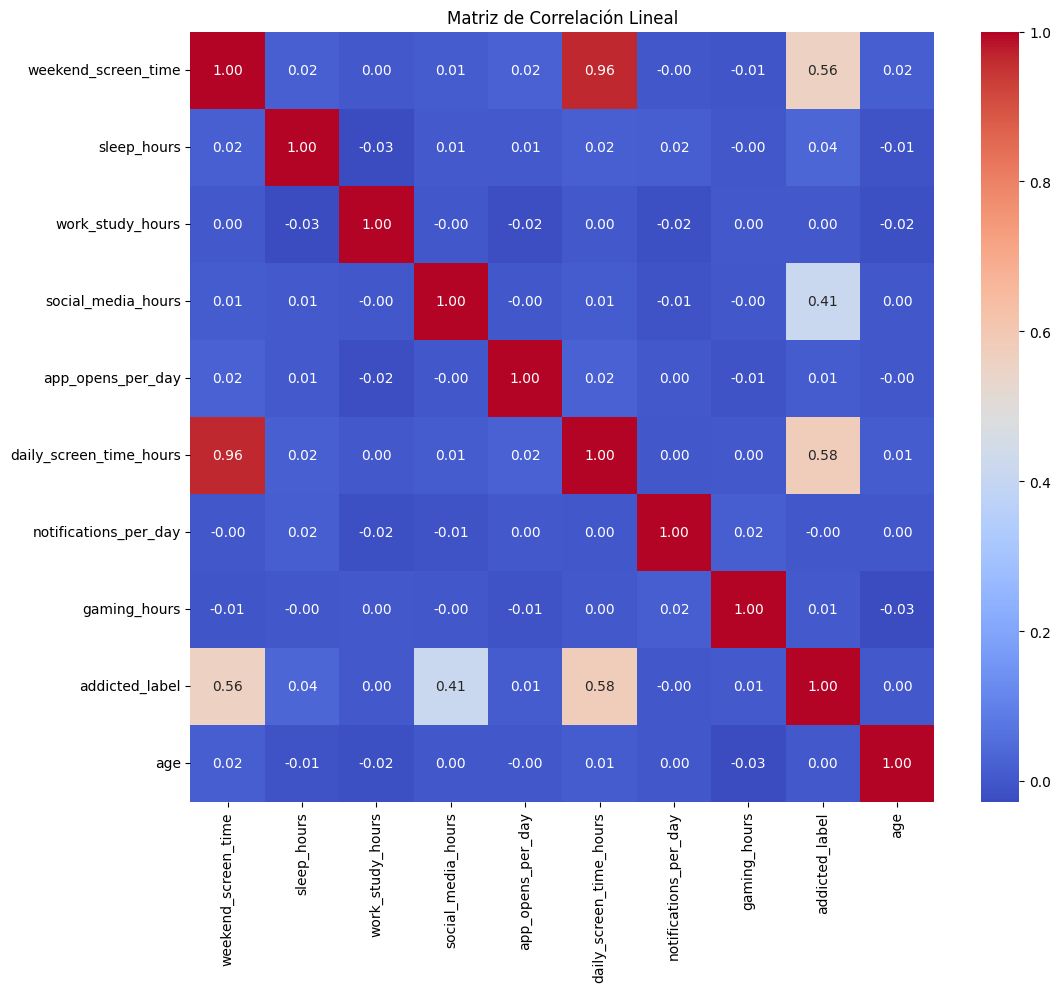

In [ ]:
plt.figure(figsize=(12, 10))
sb.heatmap(df[numcol].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación Lineal')
plt.show()

Niveles de Adicción por género


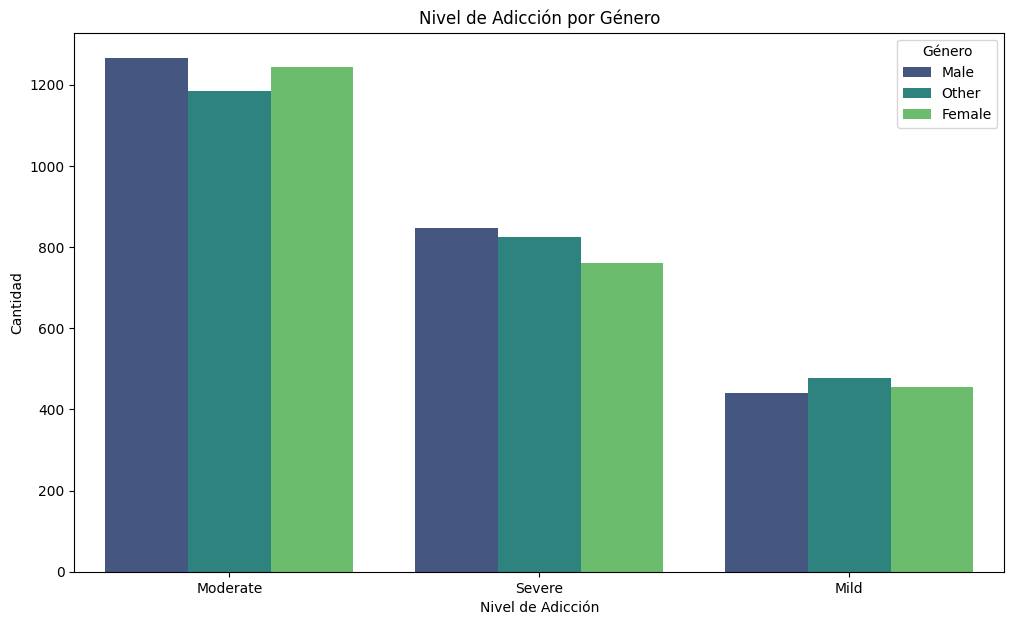

In [ ]:
plt.figure(figsize=(12, 7))
sb.countplot(data=df, x='addiction_level', hue='gender', palette='viridis', order=df['addiction_level'].value_counts().index)
plt.title('Nivel de Adicción por Género')
plt.xlabel('Nivel de Adicción')
plt.ylabel('Cantidad')
plt.legend(title='Género')
plt.show()